In [15]:
!pip install ultralytics

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
import time
import json
from google.colab.patches import cv2_imshow # Import cv2_imshow
import cv2
import numpy as np
import math
import os
import matplotlib.pyplot as plt
#import pytesseract
from PIL import Image
plt.style.use('dark_background')


Loading training YOLO license plate detection and Character Recognition Deep learning models

In [3]:
yolo_model = YOLO("/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/bd_license_plate_detector.pt")
confidence_threshold = 0.25

from tensorflow.keras.models import load_model
from google.colab import drive

ocr_model = load_model("/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/EfficientNetB0_license_plate_v2.keras")

ocr_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,161,460 (50.21 MB)

 Trainable params: 4,372,889 (16.68 MB)

 Non-trainable params: 42,791 (167.16 KB)

 Optimizer params: 8,745,780 (33.36 MB)

Preprocessing and other helper functions


In [4]:
def show_img(title, img, cmap='gray'):
    plt.figure(figsize=(6, 4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def show(title, img, cmap='gray', size=(6, 4)):
    plt.figure(figsize=size)
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

def detect_license_plates(image):
    results = yolo_model(image, conf=confidence_threshold)

    detected_plates = []

    for r in results:
        boxes = r.boxes
        if boxes is not None:
            for box in boxes:
                # Get coordinates
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                confidence = box.conf[0].cpu().numpy()

                detected_plates.append({
                    'bbox': [int(x1), int(y1), int(x2), int(y2)],
                    'confidence': float(confidence)
                })

    return detected_plates

def crop_license_plate(image, bbox, padding=10):
    x1, y1, x2, y2 = bbox
    h, w = image.shape[:2]

    # # Add padding
    # x1 = max(0, x1 - padding)
    # y1 = max(0, y1 - padding)
    # x2 = min(w, x2 + padding)
    # y2 = min(h, y2 + padding)

    # Without padding
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return image[y1:y2, x1:x2]

def visualize_results_and_return_best_bbox(image, results):
    vis_image = image.copy()
    best_box = None
    best_det_conf = None

    for result in results:
        bbox = result['bbox']
        det_conf = result['confidence']

        if best_box is None or det_conf > best_det_conf:
            best_box = bbox
            best_det_conf = det_conf

    x1, y1, x2, y2 = best_box

    # Draws bounding box of the best
    cv2.rectangle(vis_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis_image, str(best_det_conf), (x1, y2+20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    cv2_imshow(vis_image)
    return best_box

In [5]:
def unsharp_mask(image, blur_ksize=(5, 5), alpha=1.5, beta=-0.5, gamma=0):
    blurred = cv2.GaussianBlur(image, blur_ksize, 0)

    # Weighted sum: result = alpha*image + beta*blurred + gamma
    sharpened = cv2.addWeighted(image, alpha, blurred, beta, gamma)

    return sharpened

def denoise_bilateral(image):
    return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

def morphological_closing(binary_img):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)
    return closed

def find_contours(dimensions, img, original_for_draw=None):
    # Gets countour
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    lower_width, upper_width, lower_height, upper_height = dimensions

    # Sort by area, keeping top 15
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:20]

    x_cntr_list = []
    target_contours = []
    img_res = []

    # Prepare image to draw bounding boxes on
    draw_img = original_for_draw.copy() if original_for_draw is not None else np.dstack([img]*3)

    for i, cntr in enumerate(cntrs):
        x, y, w, h = cv2.boundingRect(cntr)
        if cv2.contourArea(cntr) > 200 and cv2.contourArea(cntr) < 7000:

          # if lower_width < w < upper_width and lower_height < h < upper_height:
          if True:
              x_cntr_list.append(x)

              char_copy = np.ones((64, 64), dtype=np.uint8) * 255
              char = img[y:y+h, x:x+w]
              char = cv2.resize(char, (62, 62))
              char_copy[2:64, 2:64] = char

              img_res.append(char_copy)

              # Draw box on the visualization image
              cv2.rectangle(draw_img, (x, y), (x+w, y+h), (124,252,0), 2)
              cv2.putText(draw_img, str(i+1), (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (124,252,0), 1)

    # Sorting by x-coord (left to right)
    indices = sorted(range(len(x_cntr_list)), key=lambda k: x_cntr_list[k])
    img_res = [img_res[idx] for idx in indices]

    plt.figure(figsize=(8, 6))
    plt.imshow(draw_img)
    plt.title("All Detected Contours on Plate")
    plt.axis('off')
    plt.show()

    return img_res

def crop_borders(image, top_pct=0.05, side_pct=0.0125, bottom_pct=0.0125):
    h, w = image.shape[:2]
    top = int(h * top_pct)
    bottom = int(h * (1 - bottom_pct))
    left = int(w * side_pct)
    right = int(w * (1 - side_pct))
    return image[top:bottom, left:right]

In [45]:
def preprocess_image_otsu(img):
    # Step 1: Grayscale

    enhanced = unsharp_mask(img)
    denoised = denoise_bilateral(enhanced)
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    # show("Grayscale", gray)

    # Step 2: Contrast enhancement using morphological filters
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    top_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    enhanced = cv2.add(gray, top_hat)
    enhanced = cv2.subtract(enhanced, black_hat)
    # show("Contrast Enhanced", enhanced)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # show("Otsu Binary Threshold", binary)

    # Step 4: Erosion + Dilation (noise cleanup)
    binary = cv2.erode(binary, np.ones((2,2), np.uint8), iterations=1)
    binary = cv2.dilate(binary, np.ones((2,2), np.uint8), iterations=1)
    # show("After Erosion + Dilation", binary)

    return binary

def segment_characters_otsu(image):
    # Resize plate and threshold
    img_lp = cv2.resize(image, (333, 335))

    _, binary = cv2.threshold(img_lp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.erode(binary, (3,3))
    binary = cv2.dilate(binary, (3,3))

    # # Add white border
    # binary[0:3,:] = 255
    # binary[:,0:3] = 255
    # binary[332:,:] = 255
    # binary[:,330:] = 255

    dimensions = [binary.shape[0]/6, binary.shape[0]/2, binary.shape[1]/8, 2*binary.shape[1]/3]

    plt.imshow(binary, cmap='gray')
    plt.title("Binary Image Before Contours")
    plt.axis('off')
    plt.show()

    return find_contours(dimensions, binary, original_for_draw=img_lp) # find_contours now returns two values

In [7]:
def preprocess_image_adap(img):
    # Step 1: Grayscale

    enhanced = unsharp_mask(img)
    denoised = denoise_bilateral(enhanced)
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    # show("Grayscale", gray)

    # Step 2: Contrast enhancement using morphological filters
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    top_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    enhanced = cv2.add(gray, top_hat)
    enhanced = cv2.subtract(enhanced, black_hat)
    # show("Contrast Enhanced", enhanced)

    # Step 3: Thresholding
    binary = cv2.adaptiveThreshold(
      gray,
      255,
      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # or MEAN_C
      cv2.THRESH_BINARY,
      blockSize=15,  # or 11, 21 (odd numbers only)
      C=4      # tweak this: + makes lighter, - makes darker
    )

    # _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # show("Otsu Binary Threshold", binary)

    # Step 4: Erosion + Dilation (noise cleanup)
    binary = cv2.erode(binary, np.ones((2,2), np.uint8), iterations=1)
    binary = cv2.dilate(binary, np.ones((2,2), np.uint8), iterations=1)
    # show("After Erosion + Dilation", binary)

    return binary

def segment_characters_adap(image):
    # Resize plate and threshold
    img_lp = cv2.resize(image, (333, 335))

    binary = cv2.adaptiveThreshold(
      img_lp,
      255,
      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # or MEAN_C
      cv2.THRESH_BINARY,
      blockSize=15,  # or 11, 21 (odd numbers only)
      C=4         # tweak this: + makes lighter, - makes darker
    )

    # _, binary = cv2.threshold(img_lp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.erode(binary, (3,3))
    binary = cv2.dilate(binary, (3,3))

    # Add white border
    binary[0:3,:] = 255
    binary[:,0:3] = 255
    binary[332:,:] = 255
    binary[:,330:] = 255

    dimensions = [binary.shape[0]/6, binary.shape[0]/2, binary.shape[1]/8, 2*binary.shape[1]/3]

    plt.imshow(binary, cmap='gray')
    plt.title("Binary Image Before Contours")
    plt.axis('off')
    plt.show()

    return find_contours(dimensions, binary, original_for_draw=img_lp) # find_contours now returns two values

def preprocess_for_model(contour_image):
    # Preprocess a single contour image for inference.

    # Ensuring it is the right size
    if contour_image.shape != (64, 64):
        contour_image = cv2.resize(contour_image, (64, 64))

    # Converting to 3-channel for EfficientNet
    if len(contour_image.shape) == 2:
        img_3ch = np.stack([contour_image, contour_image, img_3ch], axis=-1)
    else:
        img_3ch = contour_image

    # Normalizing to [0, 1] for better model efficiency
    img_3ch = img_3ch.astype(np.float32) / 255.0

    # Add batch dimension
    img_batch = np.expand_dims(img_3ch, axis=0)

    return img_batch

In [9]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'bo',
               'chattro', 'cho', 'dhaka', 'do', 'ga', 'gha', 'ho', 'kho',
               'khulna', 'ko', 'lo', 'maimanshing', 'metro', 'no', 'po',
               'sylhet', 'to', 'tto']

In [8]:
# function to find the digits from the plates
def find_digits():
  predicted_digits = []
  for i in range(len(pred_labels)):
    if pred_labels[i].isdigit():
      predicted_digits.append([pred_labels[i], i, confidences[i]])

  # sort the predicted digits first based on the confidence
  predicted_digits.sort(key=lambda x: x[2], reverse=True)

  # take the first 6 digits now
  predicted_digits = predicted_digits[:6]

  # sort the predicted digits based on their index
  predicted_digits.sort(key=lambda x: x[1])

  # return a string
  return ''.join([x[0] for x in predicted_digits])


# function to find the letter on the right
def find_letter():
  current_letter_class = ['bo', 'cho', 'do', 'ga', 'gha', 'ho', 'kho',
                'ko', 'lo', 'no', 'po', 'to', 'tto']

  # check if the predictions made has any of these as labels, the check happens from the end of the array
  for i in range(len(pred_labels)-1, -1, -1):
    if pred_labels[i] in current_letter_class:
      return pred_labels[i]
  return None


# function to check if metro exists
def find_metro():
  current_metro_class = ["metro"]
  for i in range(len(pred_labels)):
    # check the region and only return if conf is greater than 80
    if pred_labels[i] in current_metro_class and confidences[i] > 0.70:
      return pred_labels[i]

  if find_region() == "dhaka" or find_region() == "chattro":
    return "metro"
  return None


# function to find the region of plate
def find_region():
  current_region_classes = ['chattro', 'dhaka', 'khulna', 'maimanshing', 'sylhet']
  best_conf = 0
  best_region = None
  for i in range(len(pred_labels)):
    # check the region and only return if conf is greater than 80
    if pred_labels[i] in current_region_classes and confidences[i] > 0.7 and confidences[i] > best_conf:
      best_conf = confidences[i]
      best_region = pred_labels[i]
  return best_region

In [10]:
def predict_segmented_characters(segmented_images, show_samples=True, max_samples_to_show=50):
    """
        predicted_classes: List of predicted class indices
        predicted_labels: List of predicted class labels (strings)
        confidences: List of confidence scores
    """

    if len(segmented_images) == 0:
        print("No segmented images provided.")
        return [], [], []

    processed = []
    for img in segmented_images:
        if img.shape != (64, 64):
            img = cv2.resize(img, (64, 64))
        if len(img.shape) == 2:
            img = np.stack([img, img, img], axis=-1)
        img = img.astype(np.float32) / 255.0
        processed.append(img)

    X = np.array(processed)  # Shape: (N, 64, 64, 3)
    predictions = ocr_model.predict(X)
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_labels = [class_names[i] for i in predicted_classes]
    confidences = [predictions[i][predicted_classes[i]] for i in range(len(predicted_classes))]

    if show_samples:
        num_samples = min(max_samples_to_show, len(X))

        cols = 5
        rows = (num_samples + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows))
        if rows == 1:
            axes = [axes]
        axes = np.array(axes).ravel()

        for i in range(num_samples):
            axes[i].imshow(X[i])
            axes[i].set_title(f"Pred: {predicted_labels[i]}\nConf: {confidences[i]:.2f}")
            axes[i].axis('off')

        # Hide any unused subplots
        for i in range(num_samples, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    return predicted_classes, predicted_labels, confidences

In [11]:
def assess_plate_quality(cropped_image):
    """Assess if the plate image is good enough for processing"""
    gray = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)

    # Check blur
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Check contrast
    contrast = gray.std()

    # Check size
    h, w = gray.shape

    quality_score = 0
    if laplacian_var > 100:  # Not too blurry
        quality_score += 1
    if contrast > 20:  # Sufficient contrast
        quality_score += 1

    return quality_score >= 2, quality_score

In [91]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import restoration

def assess_image_quality(image):
    """Comprehensive image quality assessment"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # 1. Blur detection using Laplacian variance
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 2. Contrast assessment
    contrast = gray.std()

    # 3. Brightness assessment
    brightness = gray.mean()

    # 4. Shadow detection using local standard deviation
    kernel = np.ones((5,5), np.float32) / 25
    local_mean = cv2.filter2D(gray.astype(np.float32), -1, kernel)
    local_variance = cv2.filter2D((gray.astype(np.float32) - local_mean)**2, -1, kernel)
    shadow_metric = np.mean(local_variance)

    # 5. Noise level estimation
    noise_level = cv2.medianBlur(gray, 5)
    noise_metric = np.mean(np.abs(gray.astype(np.float32) - noise_level.astype(np.float32)))

    quality_metrics = {
        'blur_score': laplacian_var,
        'contrast': contrast,
        'brightness': brightness,
        'shadow_metric': shadow_metric,
        'noise_level': noise_metric,
        'is_blurry': laplacian_var < 100,
        'is_low_contrast': contrast < 20,
        'is_too_dark': brightness < 60,
        'is_too_bright': brightness > 200,
        'has_shadows': shadow_metric > 300
    }

    return quality_metrics

def adaptive_deblur(image, quality_metrics):
    if not quality_metrics['is_blurry']:
        return image

    if quality_metrics['blur_score'] < 50:
        psf = np.ones((5, 5)) / 25
        try:
            deblurred = restoration.wiener(
                image, psf, balance=0.1, clip=False, channel_axis=-1
            )
        except TypeError:
            # fallback for older scikit-image
            chans = cv2.split(image)
            out_chans = []
            for ch in chans:
                dc = restoration.wiener(ch, psf, balance=0.1, clip=False)
                out_chans.append(dc)
            deblurred = cv2.merge(out_chans)
        return (np.clip(deblurred, 0, 1) * 255).astype(np.uint8)
    else:
      # mild blur
        gaussian = cv2.GaussianBlur(image, (9, 9), 2.0)
        return cv2.addWeighted(image, 1.5, gaussian, -0.5, 0)

def adaptive_shadow_removal(image, quality_metrics):
    """Remove shadows using adaptive techniques"""
    if not quality_metrics['has_shadows']:
        return image

    # Method 1: Homomorphic filtering
    if len(image.shape) == 3:
        # Convert to LAB color space
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        # Apply homomorphic filtering to L channel
        l_log = np.log1p(l.astype(np.float32))
        l_fft = np.fft.fft2(l_log)

        # High-pass filter
        rows, cols = l.shape
        crow, ccol = rows // 2, cols // 2
        mask = np.zeros((rows, cols), np.uint8)
        r = min(crow, ccol) // 3
        cv2.circle(mask, (ccol, crow), r, 1, -1)
        mask = 1 - mask

        l_fft_filtered = l_fft * mask
        l_filtered = np.real(np.fft.ifft2(l_fft_filtered))
        l_filtered = np.expm1(l_filtered)
        l_filtered = np.clip(l_filtered, 0, 255).astype(np.uint8)

        # Reconstruct image
        lab_filtered = cv2.merge([l_filtered, a, b])
        result = cv2.cvtColor(lab_filtered, cv2.COLOR_LAB2BGR)
    else:
        # Grayscale shadow removal
        result = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(image)

    return result

def multi_scale_retinex(image, scales=[15, 80, 250]):
    """Multi-scale retinex for illumination normalization"""
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    retinex = np.zeros_like(image, dtype=np.float32)
    image_float = image.astype(np.float32) + 1.0

    for scale in scales:
        # Gaussian blur
        blurred = cv2.GaussianBlur(image_float, (0, 0), scale)
        # Retinex calculation
        retinex += np.log(image_float) - np.log(blurred + 1e-6)

    retinex = retinex / len(scales)

    # Normalize to 0-255
    retinex = cv2.normalize(retinex, None, 0, 255, cv2.NORM_MINMAX)
    return retinex.astype(np.uint8)

def enhanced_preprocessing_pipeline(image):
    """Complete preprocessing pipeline with quality assessment"""

    # Step 1: Assess image quality
    quality_metrics = assess_image_quality(image)

    print("Image Quality Assessment:")
    for key, value in quality_metrics.items():
        print(f"  {key}: {value}")

    # Step 2: Apply appropriate preprocessing
    processed_image = image.copy()

    # Handle blur
    if quality_metrics['is_blurry']:
        print("Applying deblurring...")
        processed_image = adaptive_deblur(processed_image, quality_metrics)

    # Handle shadows and lighting
    if quality_metrics['has_shadows'] or quality_metrics['is_too_dark']:
        print("Applying shadow removal...")
        processed_image = adaptive_shadow_removal(processed_image, quality_metrics)

    # Apply multi-scale retinex for illumination normalization
    if quality_metrics['is_too_dark'] or quality_metrics['is_too_bright']:
        print("Applying illumination normalization...")
        if len(processed_image.shape) == 3:
            processed_image = cv2.cvtColor(processed_image, cv2.COLOR_BGR2GRAY)
        processed_image = multi_scale_retinex(processed_image)
        processed_image = cv2.cvtColor(processed_image, cv2.COLOR_GRAY2BGR)

    # Enhanced sharpening
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharpened = cv2.filter2D(processed_image, -1, kernel)
    processed_image = cv2.addWeighted(processed_image, 0.7, sharpened, 0.3, 0)

    # Noise reduction
    processed_image = cv2.bilateralFilter(processed_image, 9, 75, 75)

    return processed_image, quality_metrics

def hybrid_thresholding(image, quality_metrics):
    """Combine multiple thresholding methods based on image quality"""

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Method 1: OTSU
    _, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Method 2: Adaptive Gaussian
    binary_adaptive = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 4
    )

    # Method 3: Adaptive Mean
    binary_adaptive_mean = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, 4
    )

    # Method 4: Multi-Otsu (if available)
    try:
        from skimage.filters import threshold_multiotsu
        thresholds = threshold_multiotsu(gray, classes=3)
        binary_multi = np.zeros_like(gray)
        binary_multi[gray > thresholds[0]] = 255
    except:
        binary_multi = binary_otsu

    # Combine methods based on quality metrics
    if quality_metrics['has_shadows']:
        # Use adaptive for shadowy images
        primary_binary = binary_adaptive
        secondary_binary = binary_otsu
    elif quality_metrics['is_low_contrast']:
        # Use multi-otsu for low contrast
        primary_binary = binary_multi
        secondary_binary = binary_adaptive_mean
    else:
        # Use OTSU for normal images
        primary_binary = binary_otsu
        secondary_binary = binary_adaptive

    # Combine using weighted average
    combined_binary = cv2.addWeighted(primary_binary, 0.7, secondary_binary, 0.3, 0)
    _, final_binary = cv2.threshold(combined_binary, 127, 255, cv2.THRESH_BINARY)

    return {
        'otsu': binary_otsu,
        'adaptive_gaussian': binary_adaptive,
        'adaptive_mean': binary_adaptive_mean,
        'multi_otsu': binary_multi,
        'combined': final_binary
    }

import numpy as np
import cv2
import matplotlib.pyplot as plt

def updated_robust_character_extraction(binary_image, min_area=200, max_area=7000):
    """
    Modified character extraction that matches the behavior of find_contours
    from segment_characters_adap, and returns segmented 64x64 character images.
    """
    # Morphological cleanup
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary_processed = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel_close)

    # Find contours
    contours, _ = cv2.findContours(binary_processed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    x_cntr_list = []
    img_res = []

    for contour in sorted(contours, key=cv2.contourArea, reverse=True)[:20]:
        area = cv2.contourArea(contour)
        if not (min_area <= area <= max_area):
            continue

        x, y, w, h = cv2.boundingRect(contour)

        # Extract character, pad to 64x64
        char = binary_image[y:y+h, x:x+w]
        char_resized = cv2.resize(char, (62, 62))
        char_padded = np.ones((64, 64), dtype=np.uint8) * 255
        char_padded[2:64, 2:64] = char_resized

        img_res.append((x, char_padded))
        x_cntr_list.append(x)

    # Sort characters by x-position
    sorted_chars = [char for _, char in sorted(img_res, key=lambda item: item[0])]
    return sorted_chars

# Example usage function
def process_license_plate_robust(cropped_plate):
    """Complete robust processing pipeline"""

    # Step 1: Enhanced preprocessing
    processed_plate, quality_metrics = enhanced_preprocessing_pipeline(cropped_plate)

    # Step 2: Hybrid thresholding
    binary_results = hybrid_thresholding(processed_plate, quality_metrics)

    # Step 3: Extract characters from each binary method
    all_characters = {}

    for method_name, binary_image in binary_results.items():
        characters = robust_character_extraction(binary_image)
        all_characters[method_name] = characters
        print(f"{method_name}: Found {len(characters)} characters")

    # Step 4: Return the method with most reasonable character count
    # For BD plates, expect 8-12 characters typically
    best_method = None
    best_count = 0

    for method_name, characters in all_characters.items():
        char_count = len(characters)
        if 6 <= char_count <= 15:  # Reasonable range
            if char_count > best_count:
                best_count = char_count
                best_method = method_name

    # If no method gives reasonable count, use the one with most characters
    if best_method is None:
        best_method = max(all_characters.keys(), key=lambda x: len(all_characters[x]))

    print(f"Selected method: {best_method} with {len(all_characters[best_method])} characters")

    return {
        'processed_plate': processed_plate,
        'binary_results': binary_results,
        'all_characters': all_characters,
        'best_characters': all_characters[best_method],
        'best_method': best_method,
        'quality_metrics': quality_metrics
    }

## Loading test image

### Detecting the License plate using YOLO


0: 480x640 1 license_plate, 759.1ms
Speed: 3.2ms preprocess, 759.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


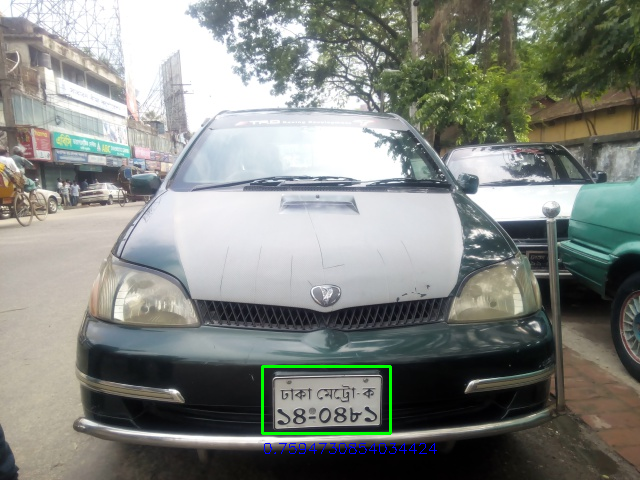

In [139]:
image_path = "/content/drive/MyDrive/datasets/unseen-test-images/Vehicle1601.jpg"
image = cv2.imread(str(image_path))

results = detect_license_plates(image)

bbox = visualize_results_and_return_best_bbox(image, results)

cropped_image = crop_license_plate(image, bbox)

Detect using the hybrid preprocessing methods


In [ ]:
quality_metrics = assess_image_quality(cropped_image)

processed_image, quality_metrics = enhanced_preprocessing_pipeline(cropped_image)

binary_plates = hybrid_thresholding(processed_image)

binary_plate_hybrid = crop_borders(binary_plates)

cols = 8
rows = math.ceil(len(characters_otsu) / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i, char in enumerate(characters_otsu):
    plt.subplot(rows, cols, i + 1)
    # char = cv2.bitwise_not(char)
    plt.imshow(char, cmap='gray')
    plt.axis("on")
    plt.title(f"Character {i+1}\n{char.shape}")

plt.suptitle("Segmented Characters (4 per row)")
plt.tight_layout()
plt.show()

In [ ]:
pred_indices, pred_labels, confidences = predict_segmented_characters(characters_otsu, show_samples=True)

print("\n")

print(f"{find_region()} {find_metro()} - {find_letter()} {find_digits()}")

Detecting using enhanced image preprocessing and otsu

Image Quality Assessment:
  blur_score: 4145.922028464872
  contrast: 60.25141847493099
  brightness: 108.62126865671642
  shadow_metric: 619.71240234375
  noise_level: 11.163129806518555
  is_blurry: False
  is_low_contrast: False
  is_too_dark: False
  is_too_bright: False
  has_shadows: True
Applying shadow removal...


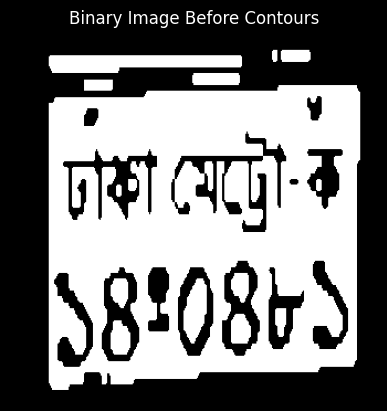

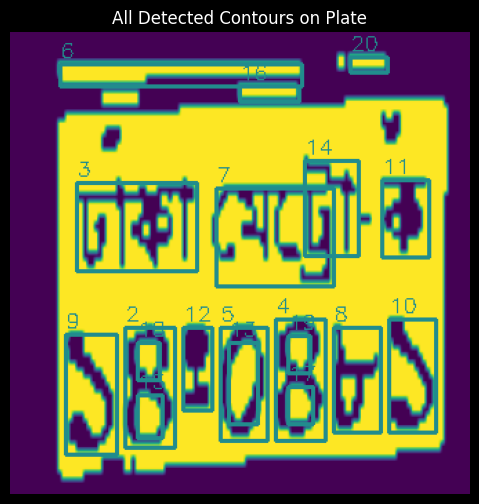

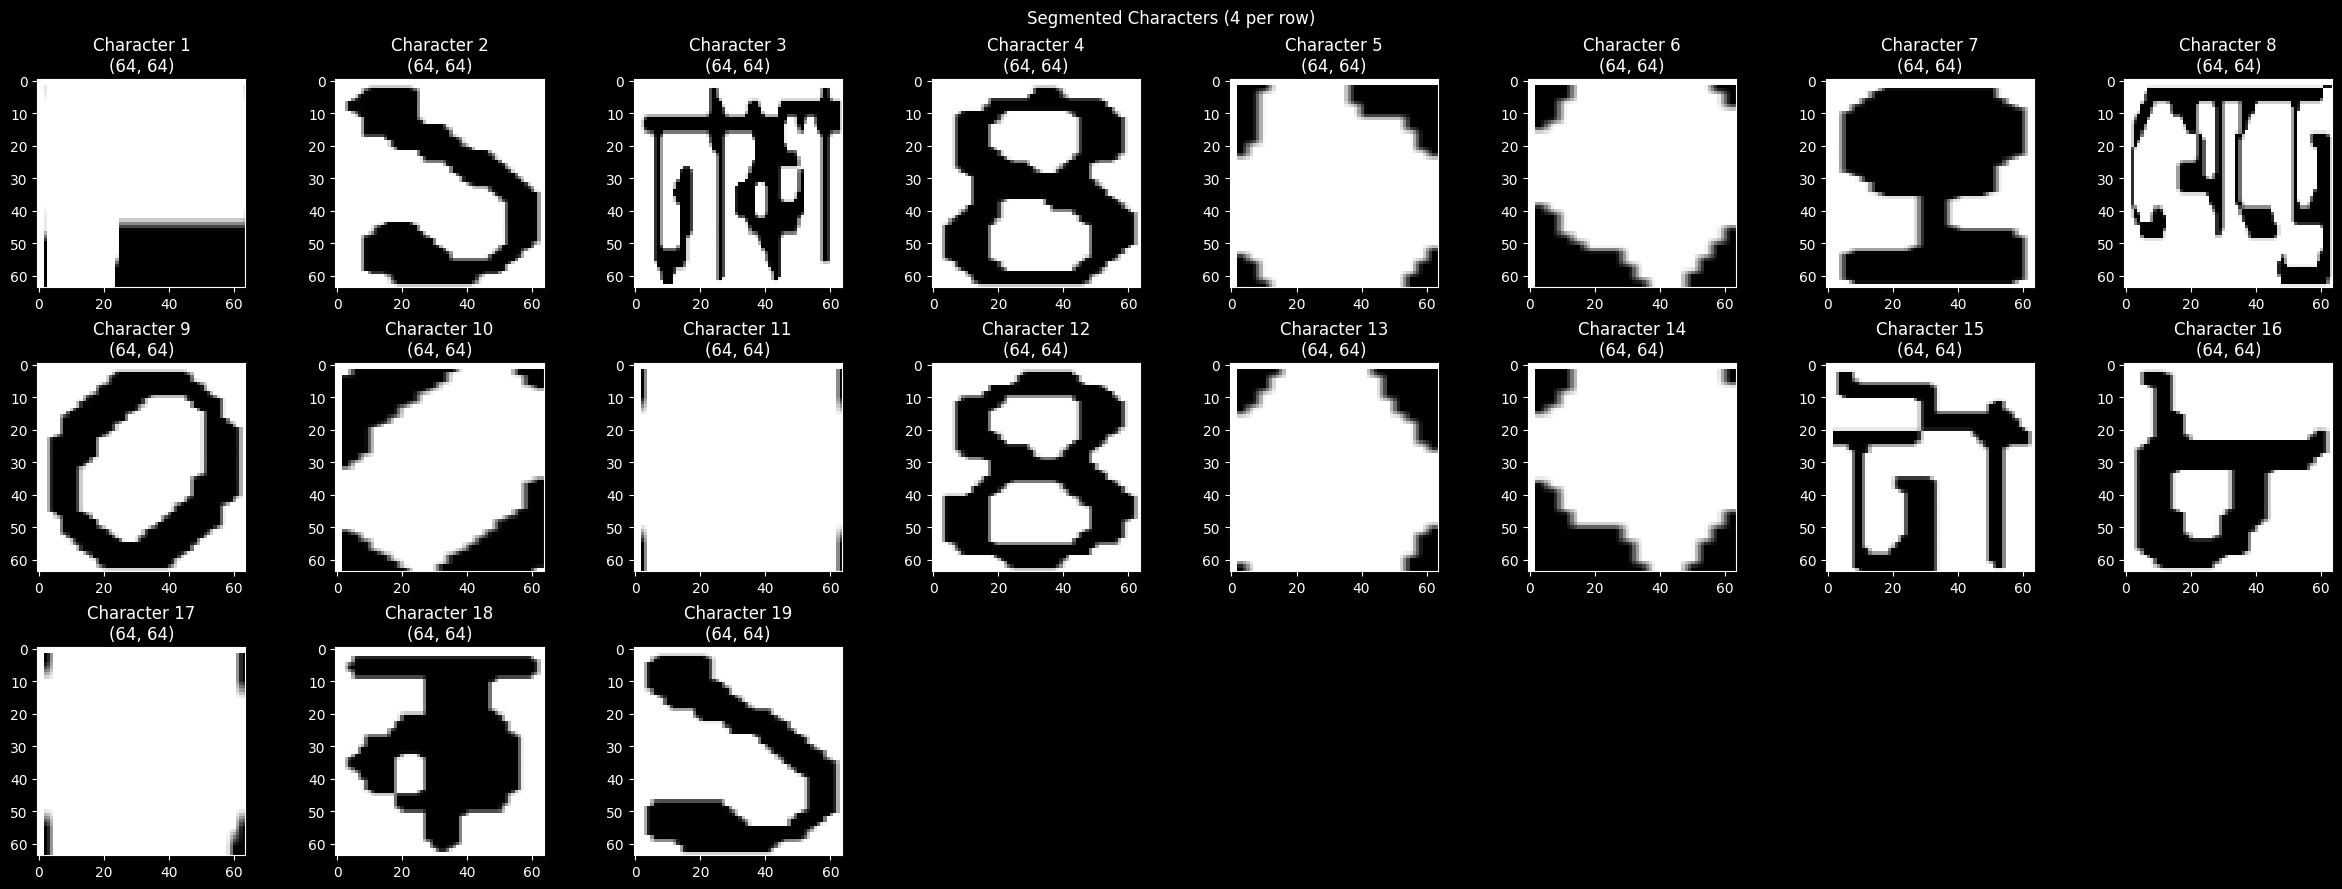

In [140]:
quality_metrics = assess_image_quality(cropped_image)

processed_image, quality_metrics = enhanced_preprocessing_pipeline(cropped_image)

binary_plate_otsu = preprocess_image_otsu(processed_image)
binary_plate_otsu = crop_borders(binary_plate_otsu)
#closed_img = morphological_closing(binary_plate)
characters_otsu = segment_characters_otsu(binary_plate_otsu)

cols = 8
rows = math.ceil(len(characters_otsu) / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i, char in enumerate(characters_otsu):
    plt.subplot(rows, cols, i + 1)
    # char = cv2.bitwise_not(char)
    plt.imshow(char, cmap='gray')
    plt.axis("on")
    plt.title(f"Character {i+1}\n{char.shape}")

plt.suptitle("Segmented Characters (4 per row)")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step


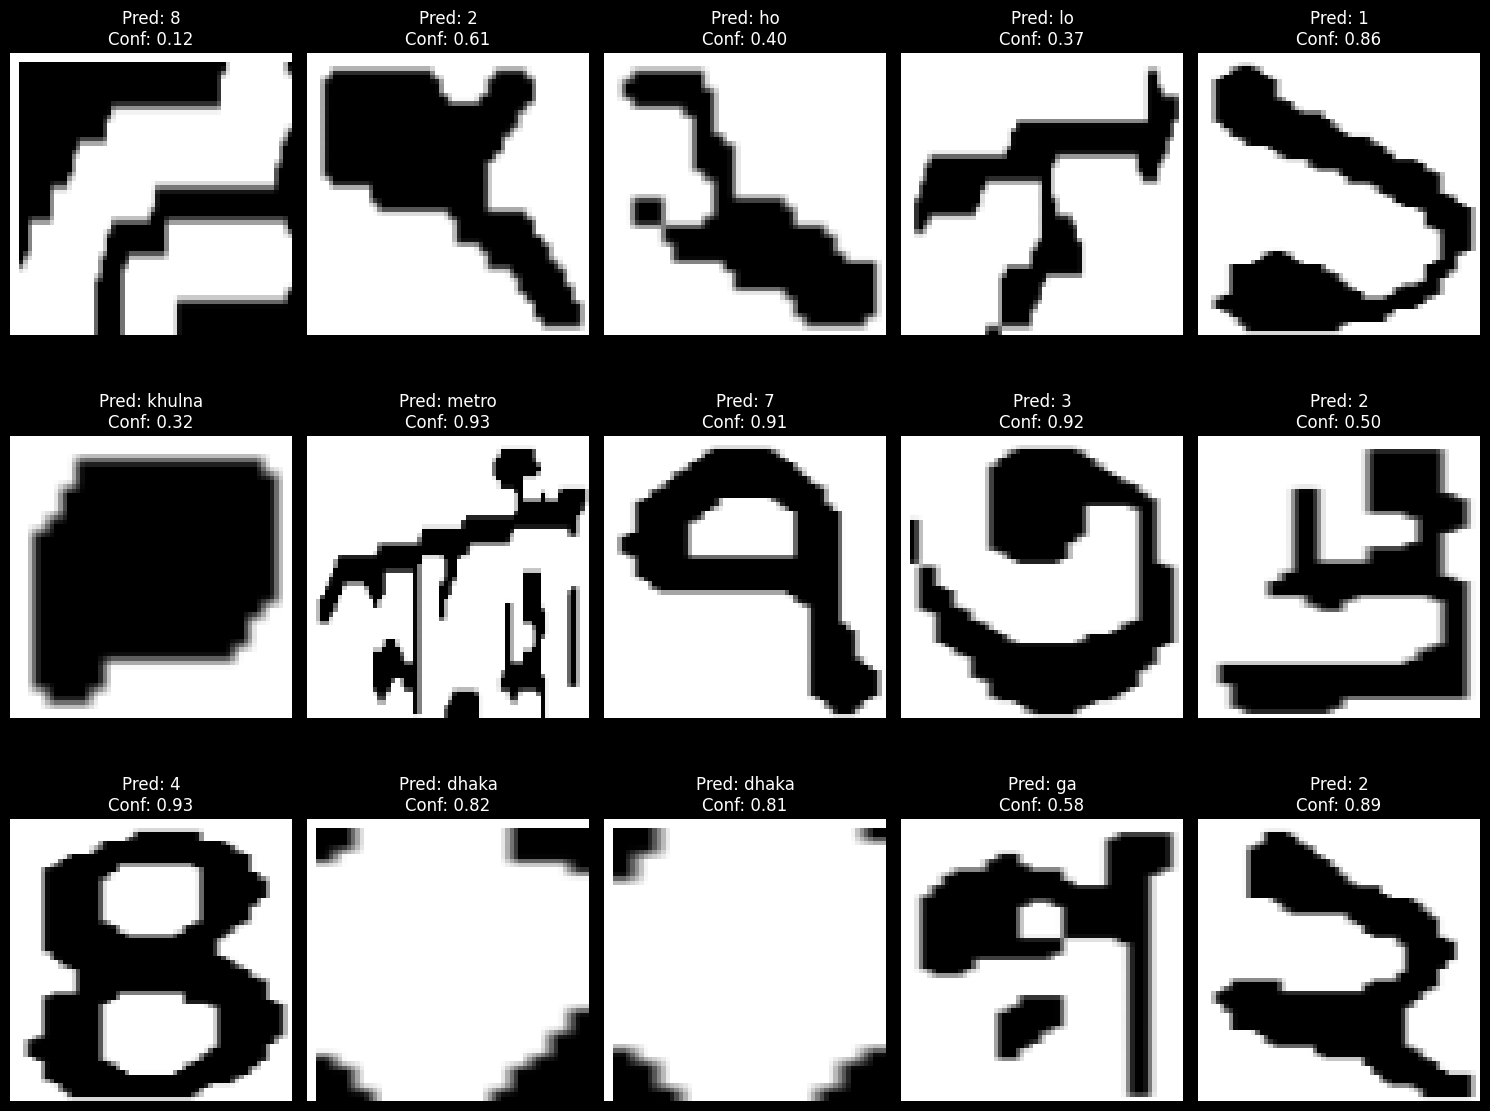



dhaka metro - ga 217342


In [127]:
pred_indices, pred_labels, confidences = predict_segmented_characters(characters_otsu, show_samples=True)

print("\n")

print(f"{find_region()} {find_metro()} - {find_letter()} {find_digits()}")

Detecting using enhanced image preprocessing and adap


Image Quality Assessment:
  blur_score: 820.8773762077589
  contrast: 56.6794332218149
  brightness: 145.32161616161616
  shadow_metric: 271.66119384765625
  noise_level: 6.667936325073242
  is_blurry: False
  is_low_contrast: False
  is_too_dark: False
  is_too_bright: False
  has_shadows: False


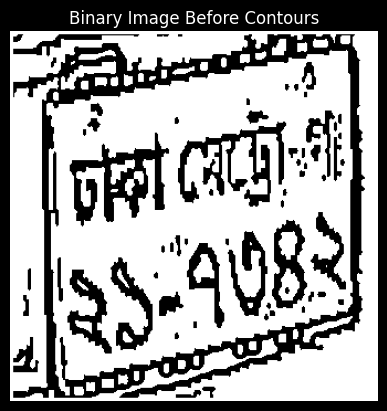

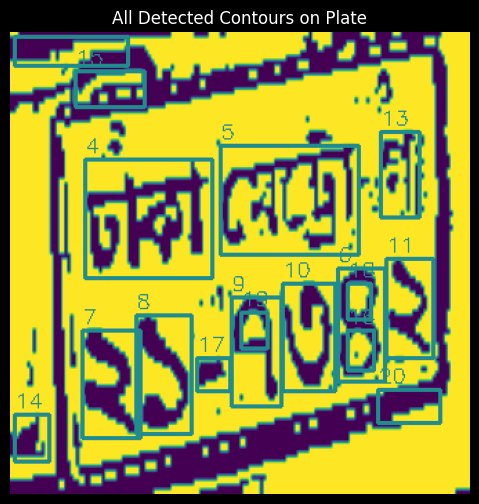

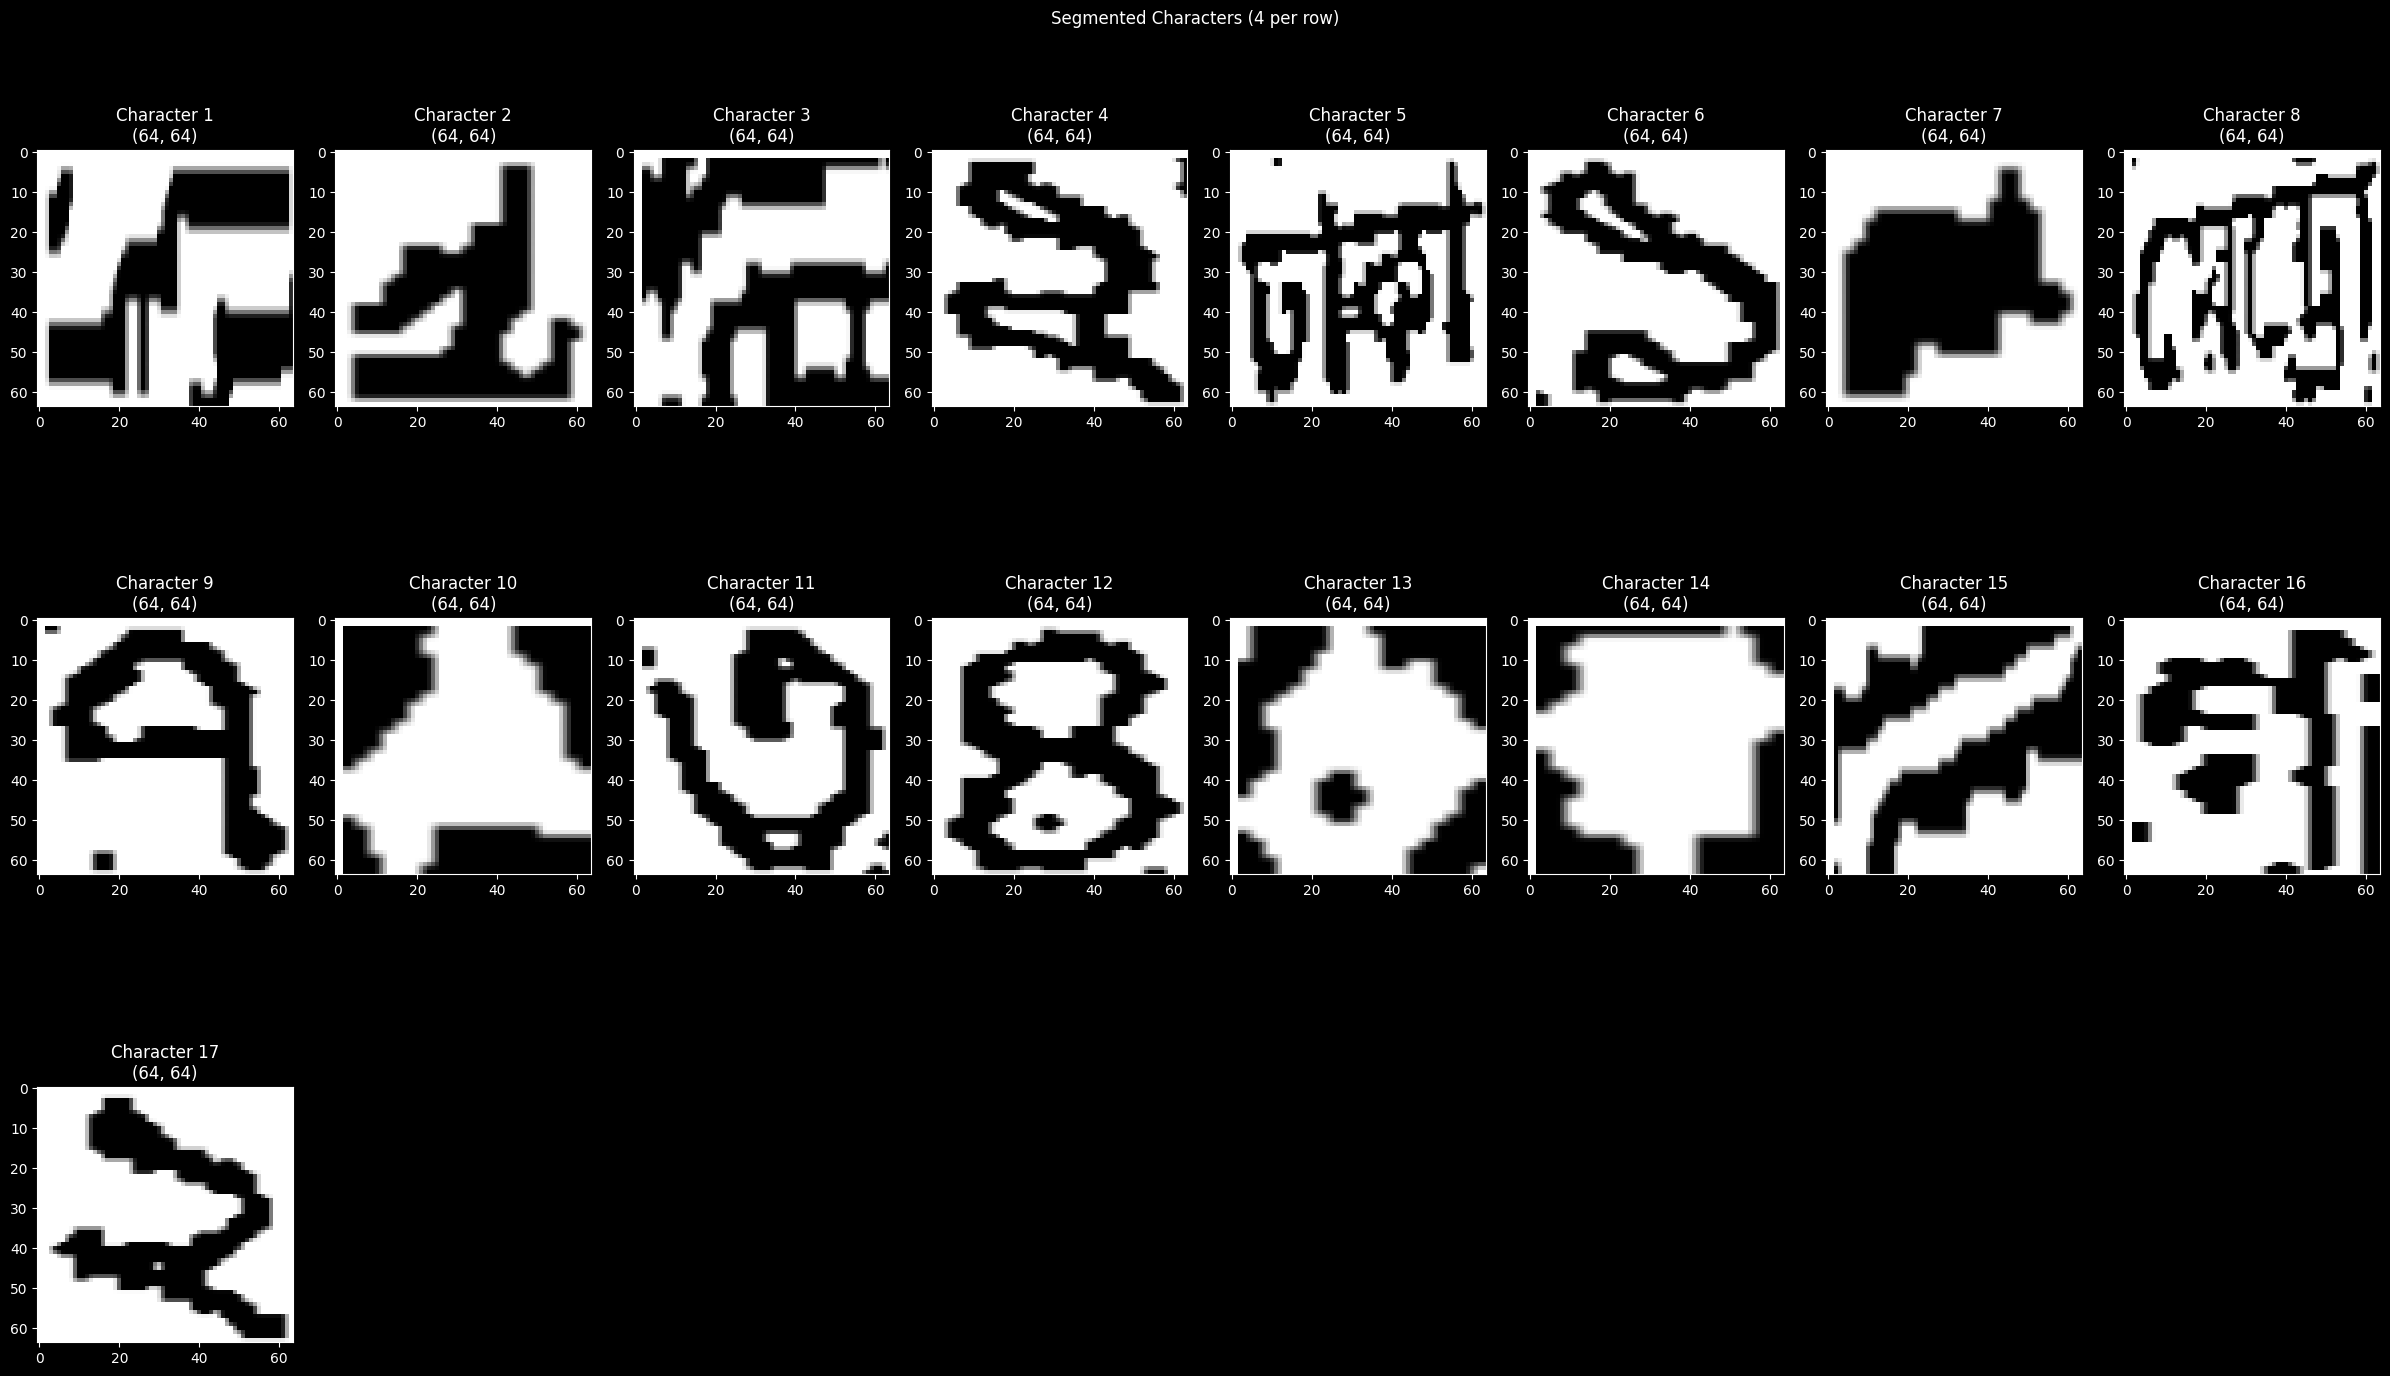

In [125]:
quality_metrics = assess_image_quality(cropped_image)

processed_image, quality_metrics = enhanced_preprocessing_pipeline(cropped_image)

binary_plate_adap = preprocess_image_adap(processed_image)
binary_plate_adap = crop_borders(binary_plate_adap)
#closed_img = morphological_closing(binary_plate)
characters_adap = segment_characters_adap(binary_plate_adap)

cols = 8
rows = math.ceil(len(characters_adap) / cols)

plt.figure(figsize=(cols * 3, rows * 5))

for i, char in enumerate(characters_adap):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(char, cmap='gray')
    plt.axis("on")
    plt.title(f"Character {i+1}\n{char.shape}")

plt.suptitle("Segmented Characters (4 per row)")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


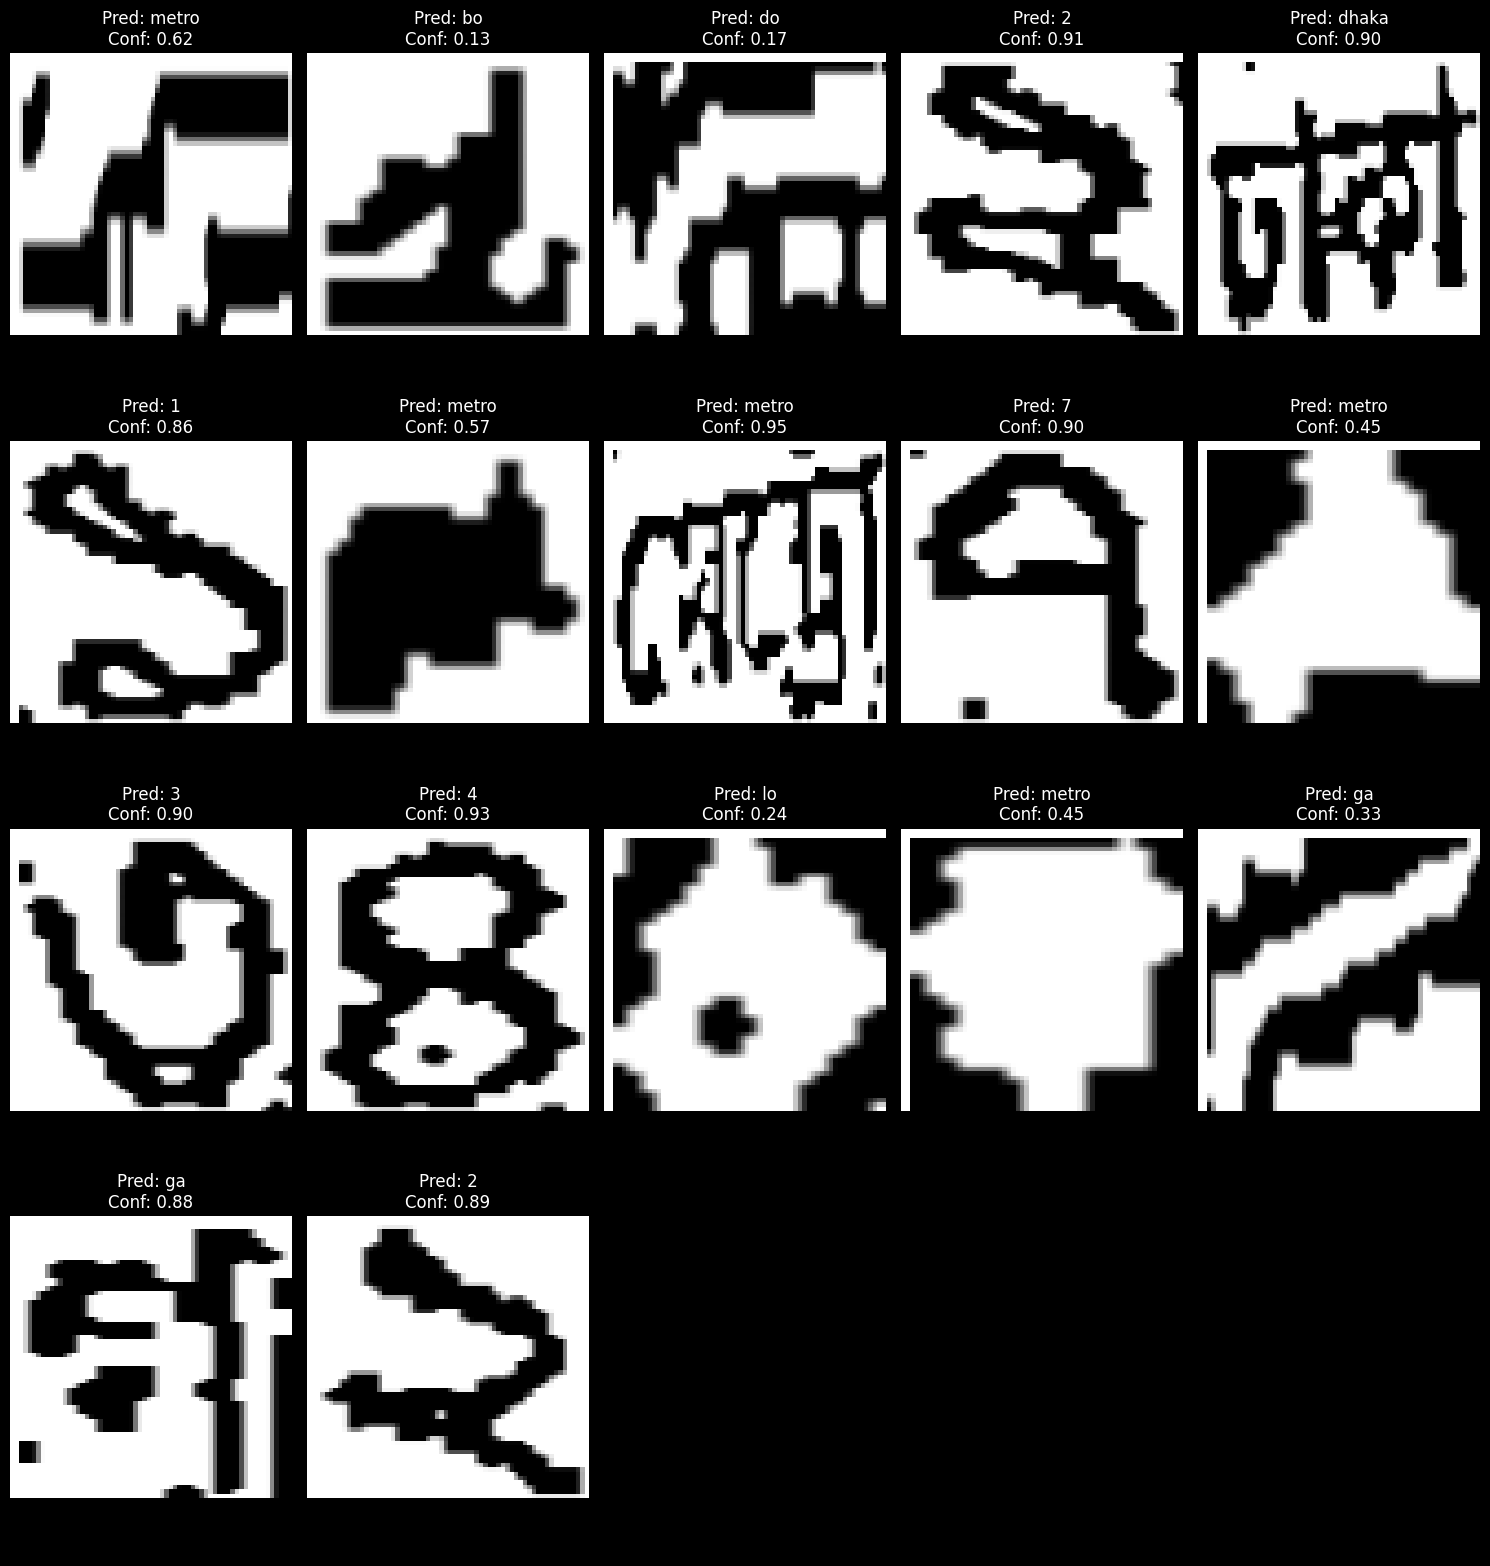

dhaka metro - ga 217342


In [126]:
pred_indices, pred_labels, confidences = predict_segmented_characters(characters_adap, show_samples=True)

print(f"{find_region()} {find_metro()} - {find_letter()} {find_digits()}")

## Detecting characters and keywords for daylight images

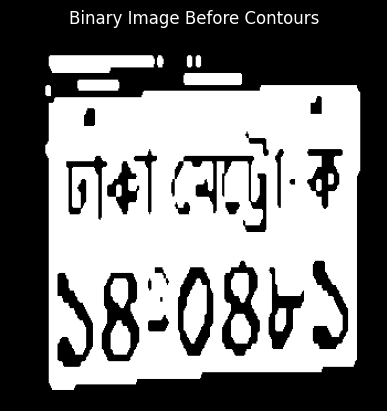

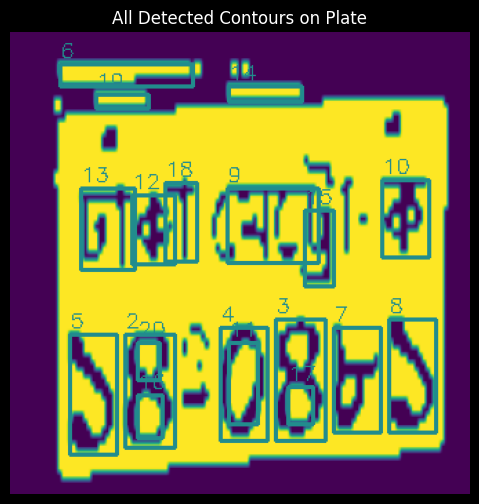

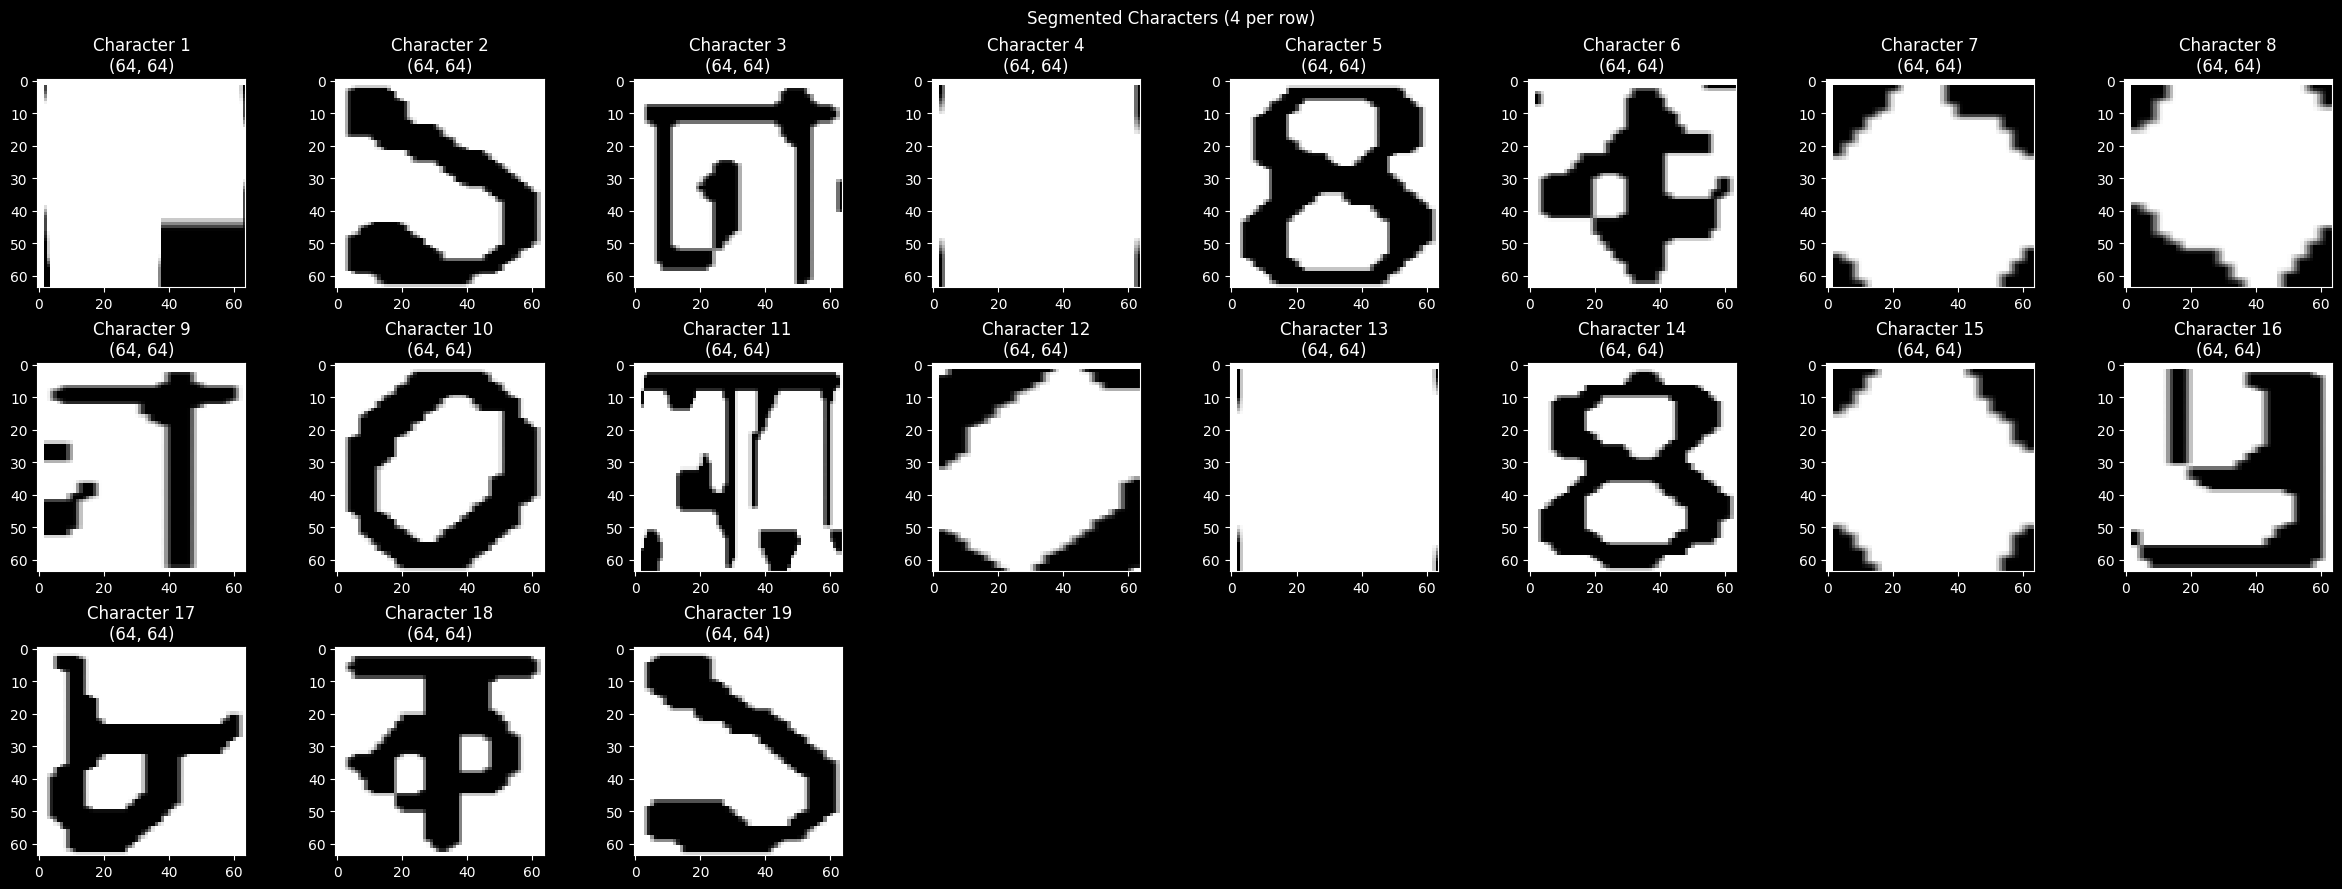

In [141]:
binary_plate_otsu = preprocess_image_otsu(cropped_image)
binary_plate_otsu = crop_borders(binary_plate_otsu)
#closed_img = morphological_closing(binary_plate)
characters_otsu = segment_characters_otsu(binary_plate_otsu)

cols = 8
rows = math.ceil(len(characters_otsu) / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i, char in enumerate(characters_otsu):
    plt.subplot(rows, cols, i + 1)
    # char = cv2.bitwise_not(char)
    plt.imshow(char, cmap='gray')
    plt.axis("on")
    plt.title(f"Character {i+1}\n{char.shape}")

plt.suptitle("Segmented Characters (4 per row)")
plt.tight_layout()
plt.show()

## Detecting the extracted characters from the license plate region and predicting

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step


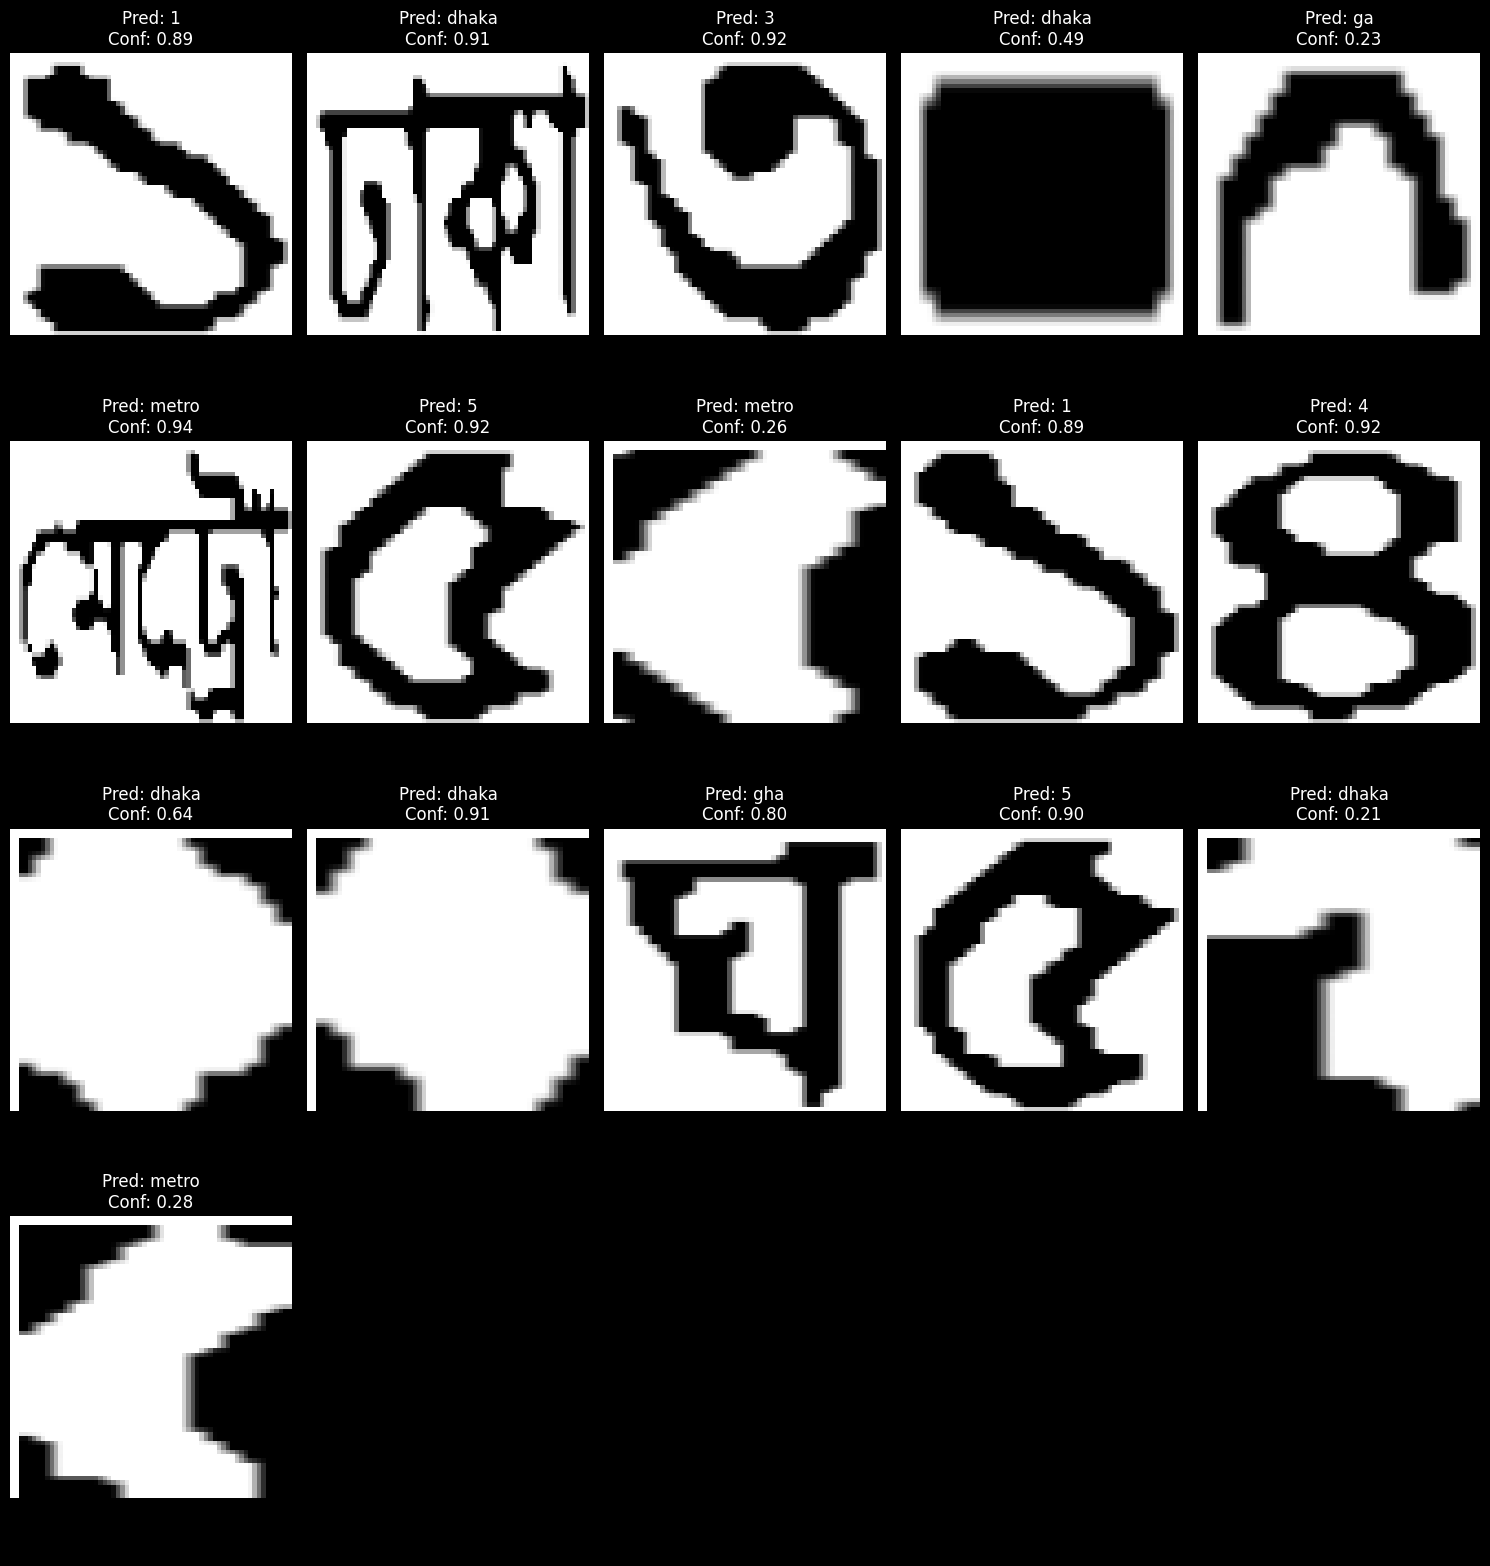



dhaka metro - gha 135145


In [138]:
pred_indices, pred_labels, confidences = predict_segmented_characters(characters_otsu, show_samples=True)

print("\n")

print(f"{find_region()} {find_metro()} - {find_letter()} {find_digits()}")

## Detecting characters and keywords for images with shadow and High brightness or High Contrast

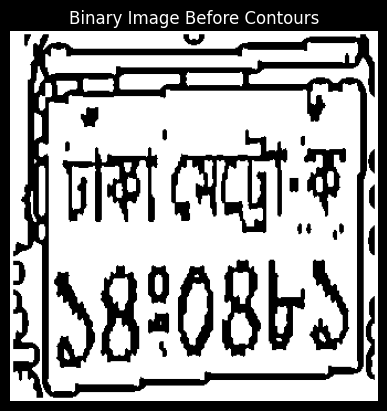

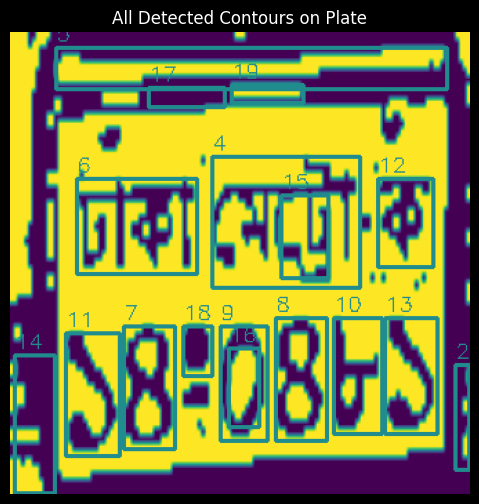

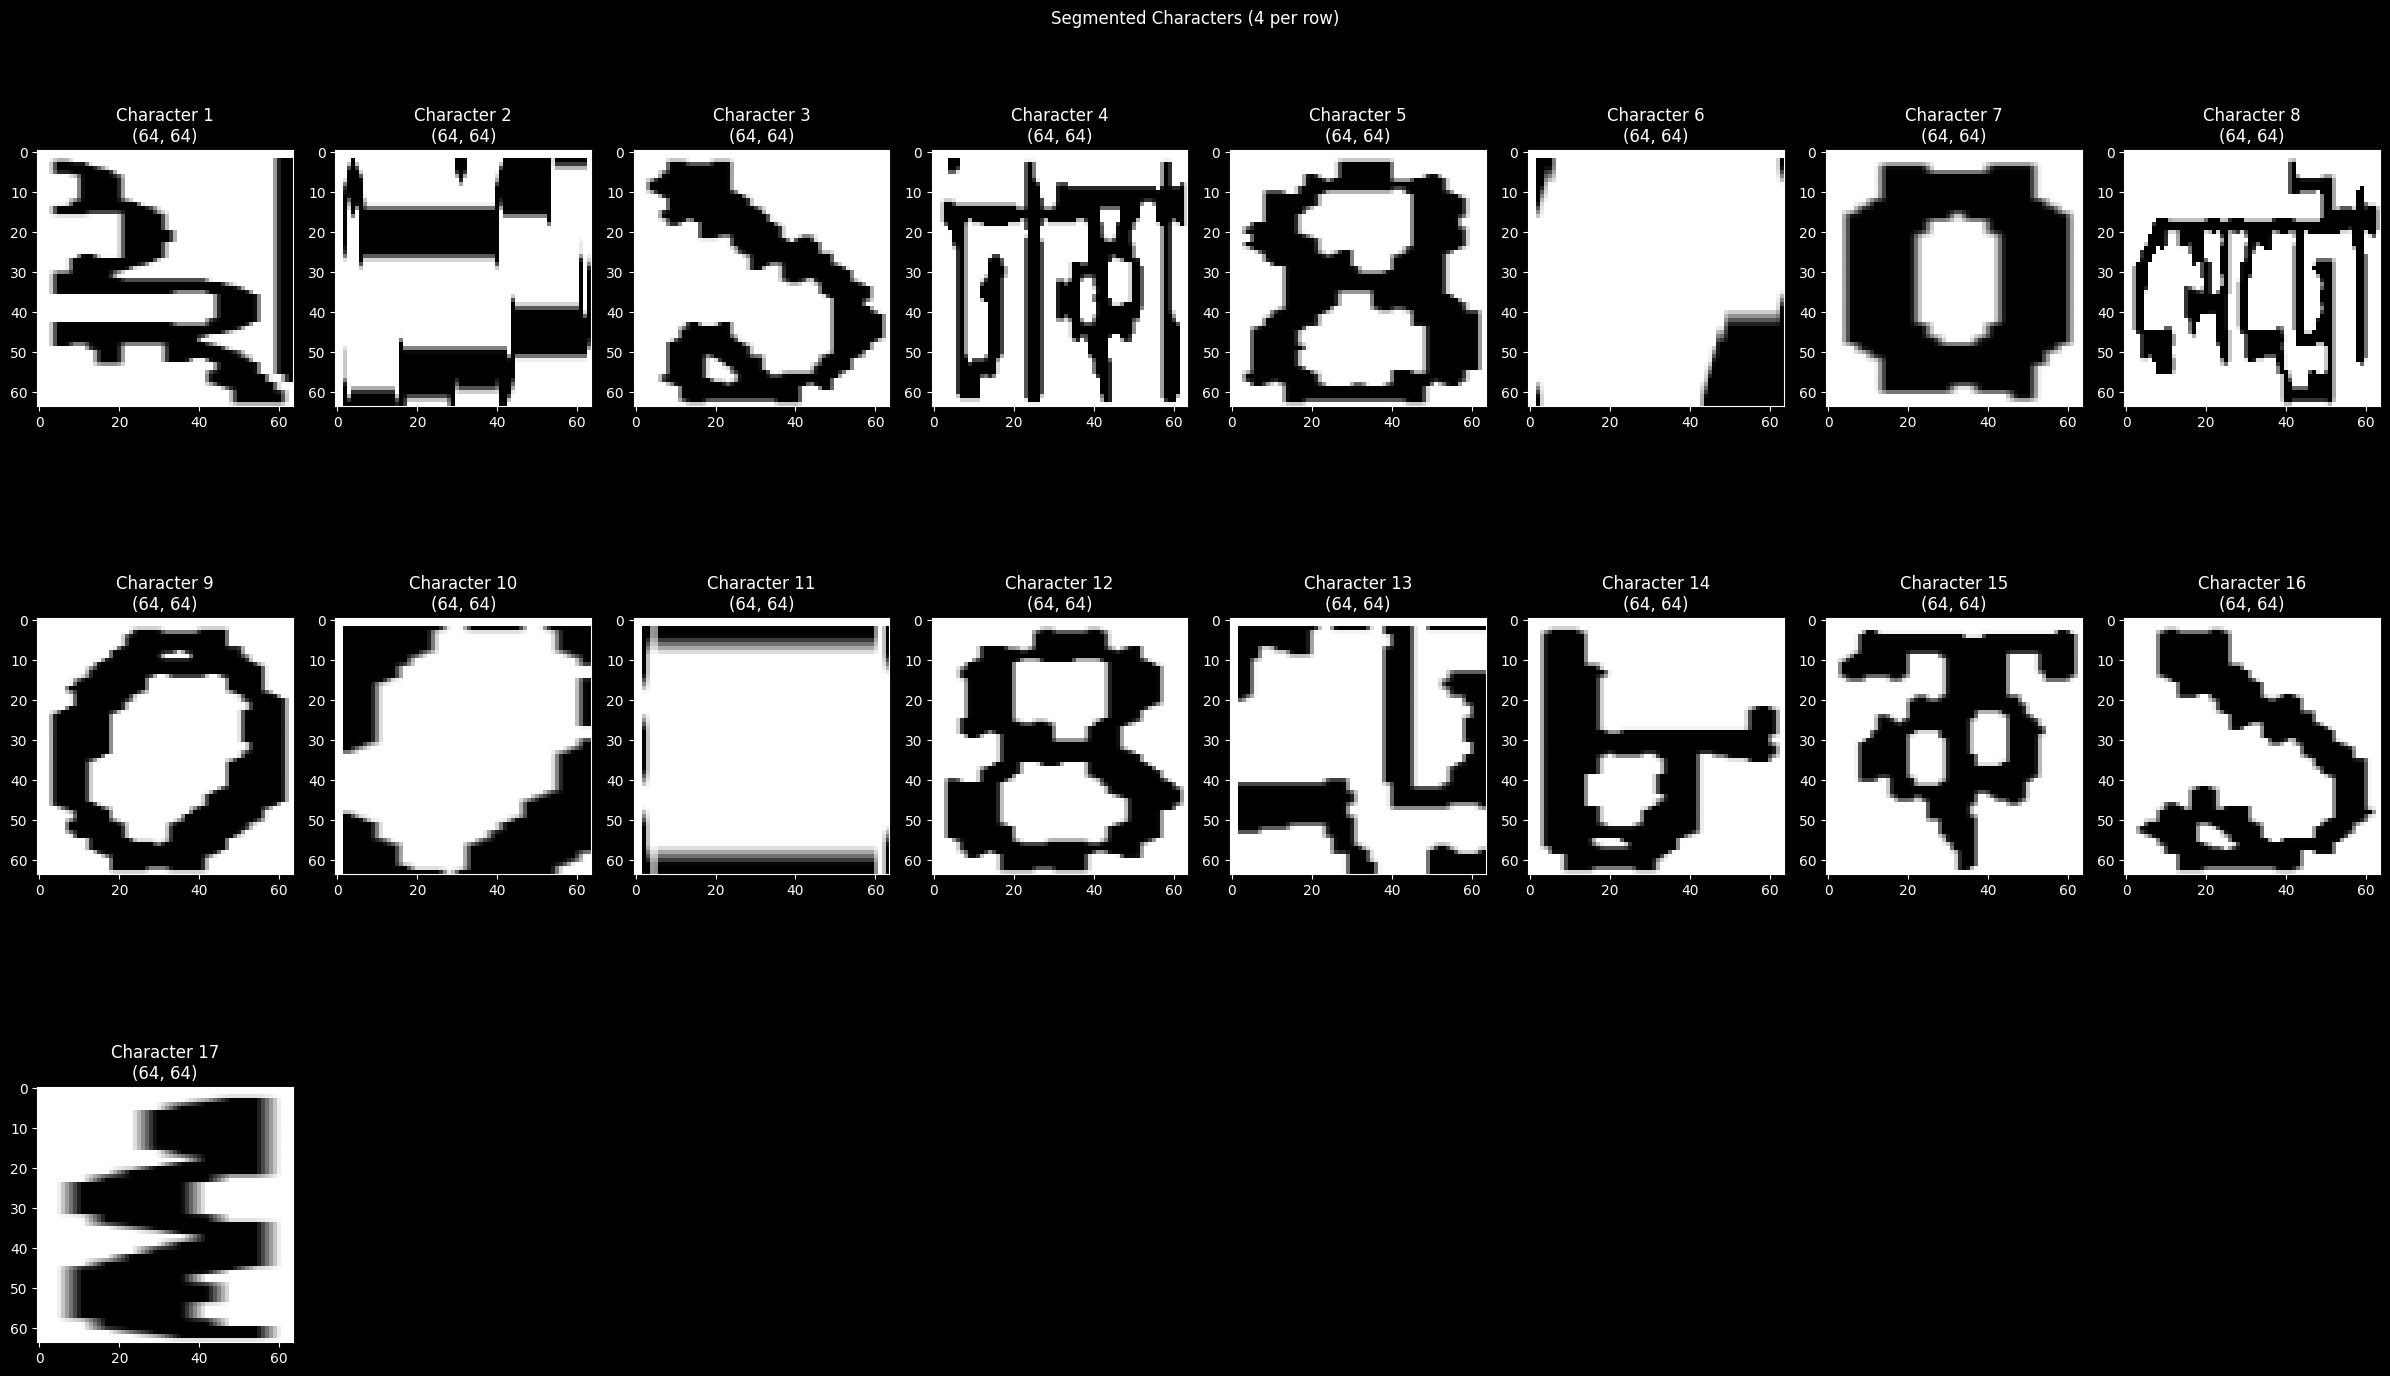

In [142]:
binary_plate_adap = preprocess_image_adap(cropped_image)
binary_plate_adap = crop_borders(binary_plate_adap)
#closed_img = morphological_closing(binary_plate)
characters_adap = segment_characters_adap(binary_plate_adap)

cols = 8
rows = math.ceil(len(characters_adap) / cols)

plt.figure(figsize=(cols * 3, rows * 5))

for i, char in enumerate(characters_adap):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(char, cmap='gray')
    plt.axis("on")
    plt.title(f"Character {i+1}\n{char.shape}")

plt.suptitle("Segmented Characters (4 per row)")
plt.tight_layout()
plt.show()

## Detecting the extracted characters from the license plate region and predicting

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step


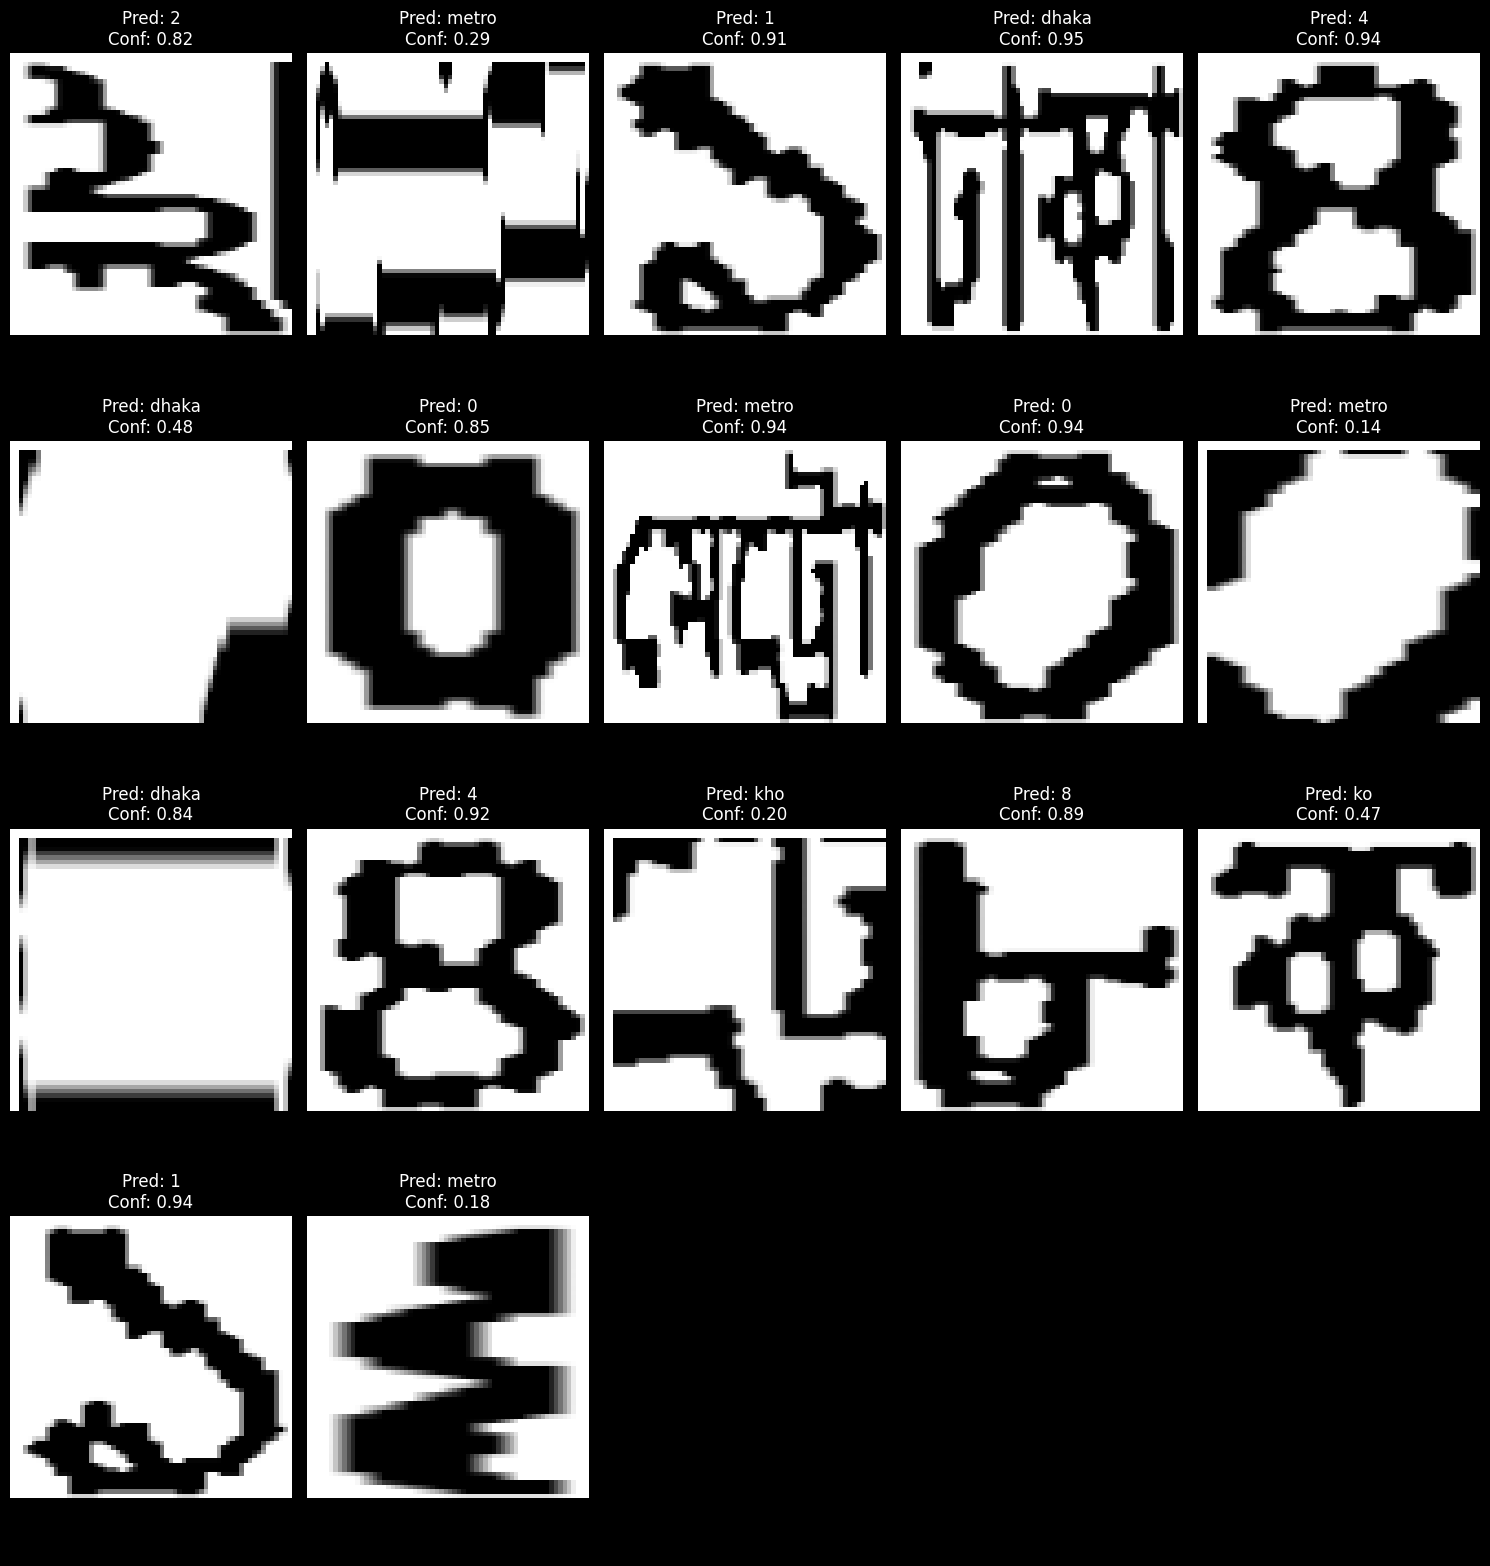

dhaka metro - ko 140481


In [143]:
pred_indices, pred_labels, confidences = predict_segmented_characters(characters_adap, show_samples=True)

print(f"{find_region()} {find_metro()} - {find_letter()} {find_digits()}")